In [1]:
from src import *
# ----------------------------------------------------------------------------------
# Plotting parameters
# ----------------------------------------------------------------------------------
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    'text.latex.preamble':r'\usepackage{amsmath}',
    'text.latex.preamble':r'\usepackage{fourier}'
})
w, l, l_log = 1.25, 10, 6
pad, lpad, shrink = 0.12, 5, 0.8

In [3]:
conf = inifix.load("idefix.ini")
n_average = int(conf["TimeIntegrator"]["tstop"] / conf["Output"]["analysis"]) + 1
n_vtk = int(conf["TimeIntegrator"]["tstop"] / conf["Output"]["vtk"]) + 1
r_min = conf["Grid"]["X1-grid"][1]
r_max = conf["Grid"]["X1-grid"][-1]
n_r = conf["Grid"]["X1-grid"][2]
epsilon = conf["Setup"]["epsilon"]
alpha = conf["Setup"]["alpha"]
densityFloor = conf["Setup"]["densityFloor"]
gravity = conf["Setup"]["gravity"]
beta_0 = conf["Setup"]["tilt"] * np.pi/180
spin = conf["Setup"]["spin"]

# Reading the analysis files
t, M_tot = READ_BOX_AVERAGE()
r, Sigma, rho_mean, L, beta, gamma, LBH, betaBH, gammaBH, rho_Vr = READ_RADIAL_AVERAGE(n_average, n_r, beta_0)

In [4]:
# Time
t_orbit = 2*np.pi*(r_min**1.5) / np.sqrt(1 - 2.5*epsilon**2)       # This is an input
omega_orbit = 1/t_orbit
n_orbit = (t[-1]*omega_orbit)
# n_orbit = 500       # Good for t_max = 3200.1 and r_min = 1
t *= omega_orbit
wh_t_final = np.where(t >= n_orbit)[0][0]
T, R = np.meshgrid(t, r, indexing="ij")
# Radial averages
LBH_unit = np.zeros_like(LBH)
LBH_unit[:,:,0] = LBH[:,:,0] / np.sqrt(LBH[:,:,0]**2 + LBH[:,:,1]**2 + LBH[:,:,2]**2)
LBH_unit[:,:,1] = LBH[:,:,1] / np.sqrt(LBH[:,:,0]**2 + LBH[:,:,1]**2 + LBH[:,:,2]**2)
LBH_unit[:,:,2] = LBH[:,:,2] / np.sqrt(LBH[:,:,0]**2 + LBH[:,:,1]**2 + LBH[:,:,2]**2)
psi = R * np.sqrt(np.gradient(LBH_unit[:,:,0], r, axis=1)**2 + np.gradient(LBH_unit[:,:,1], r, axis=1)**2 + np.gradient(LBH_unit[:,:,2], r, axis=1)**2)      # Warp profile
zeta = np.gradient(betaBH, t, axis=0)    # Nodal precession frequency
eta = np.gradient(gammaBH, t, axis=0)     # Apsidal precession frequency
# zeta = np.mean(np.gradient(betaBH, t, axis=0), axis=0)     # Nodal precession frequency
# eta = np.mean(np.gradient(gammaBH, t, axis=0), axis=0)      # Apsidal precession frequency
# Must implement for every gravitationnal potential ! --------------------------------------------------------------------------------------------------------------
if spin != 0:
    if gravity == "Kepler":
        omega2_E = 1/R**3 - 2*spin/R**(9/2)
        zeta_th = 1/omega2_E * (-4*spin) / (2*R**(3/2) - 4*spin)
        eta_th = 1/omega2_E * 3*spin / (2*R**(3/2) - 4*spin)
    elif gravity == "Einstein":
        omega2_E = 1/R**3 * (1 + 6/R) - 2*spin/R**(9/2)
        zeta_th = -2*spin / (omega2_E * R**(9/2))
        eta_th = -1/(2*omega2_E) * (6/R**4 - 3*spin/R**(9/2))
    t_visc = 1 / (alpha * np.sqrt(omega2_E)) * epsilon**(-2)       # To verify (especially that omega)
    M_dot_visc = Sigma[0,0]*(2*np.pi*R[0,0]**2*epsilon) / t_visc
    M_dot = 2*np.pi*R * Sigma * (-rho_Vr / rho_mean)
    M_dot /= M_dot_visc
    zeta /= zeta_th
    eta /= eta_th
else:
    omega_K = KEPLER(r)
    t_visc = 1 / (alpha * np.sqrt(omega_K)) * epsilon**(-2)       # To verify (especially that omega)
    M_dot_visc = Sigma[0,0]*(2*np.pi*R[0,0]**2*epsilon) / t_visc
    M_dot = 2*np.pi*R * Sigma * (-rho_Vr / rho_mean)
    M_dot /= M_dot_visc

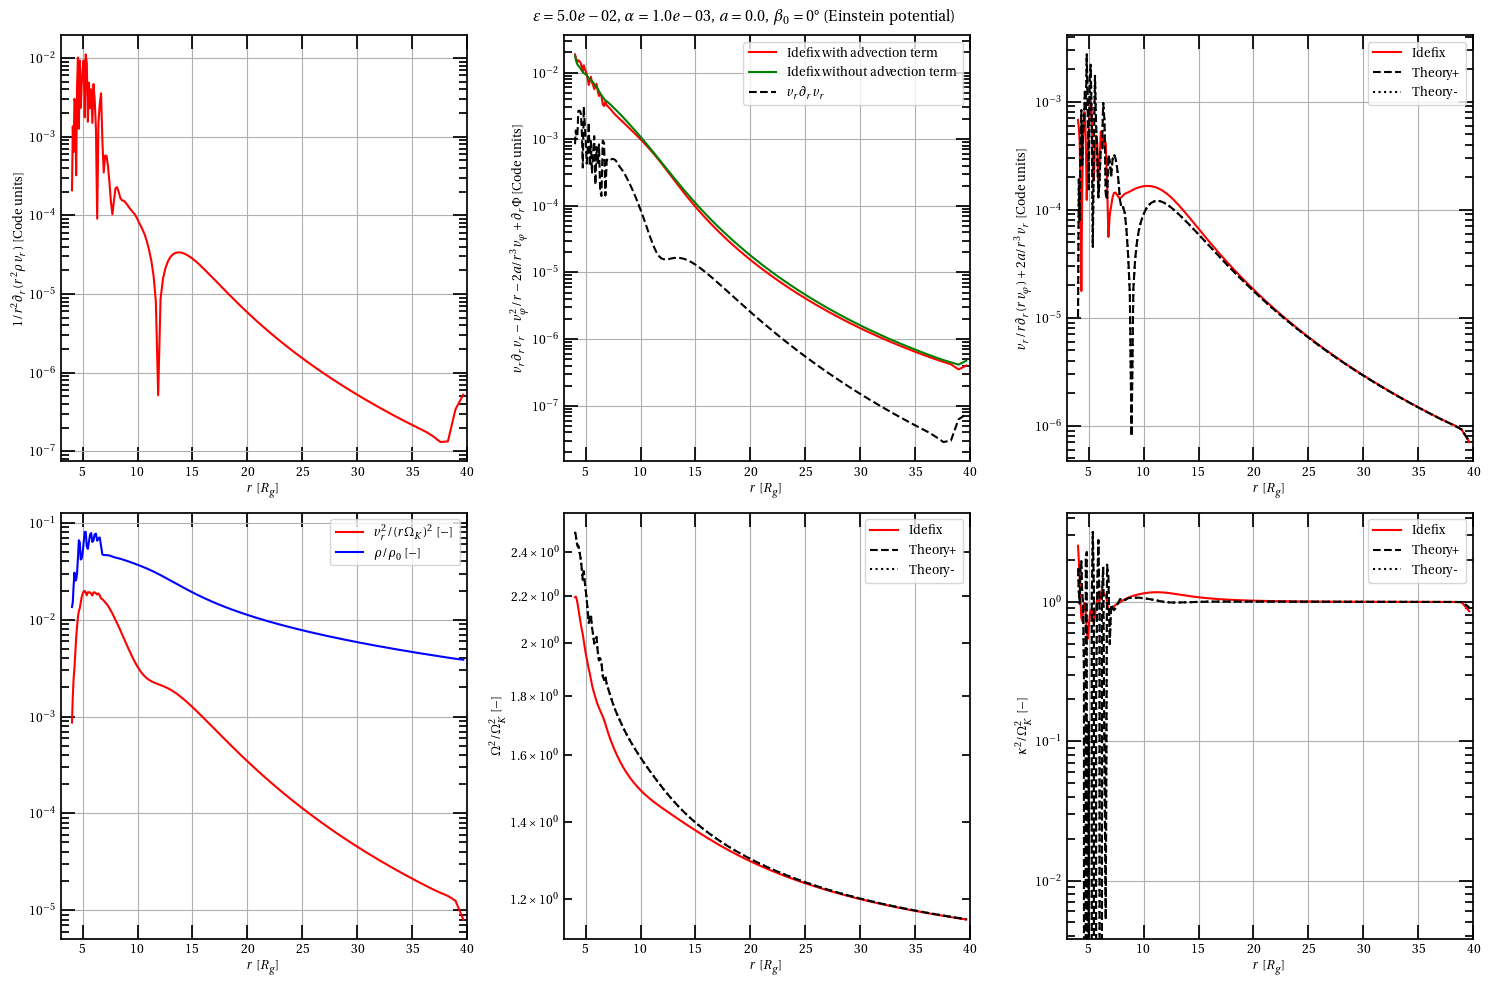

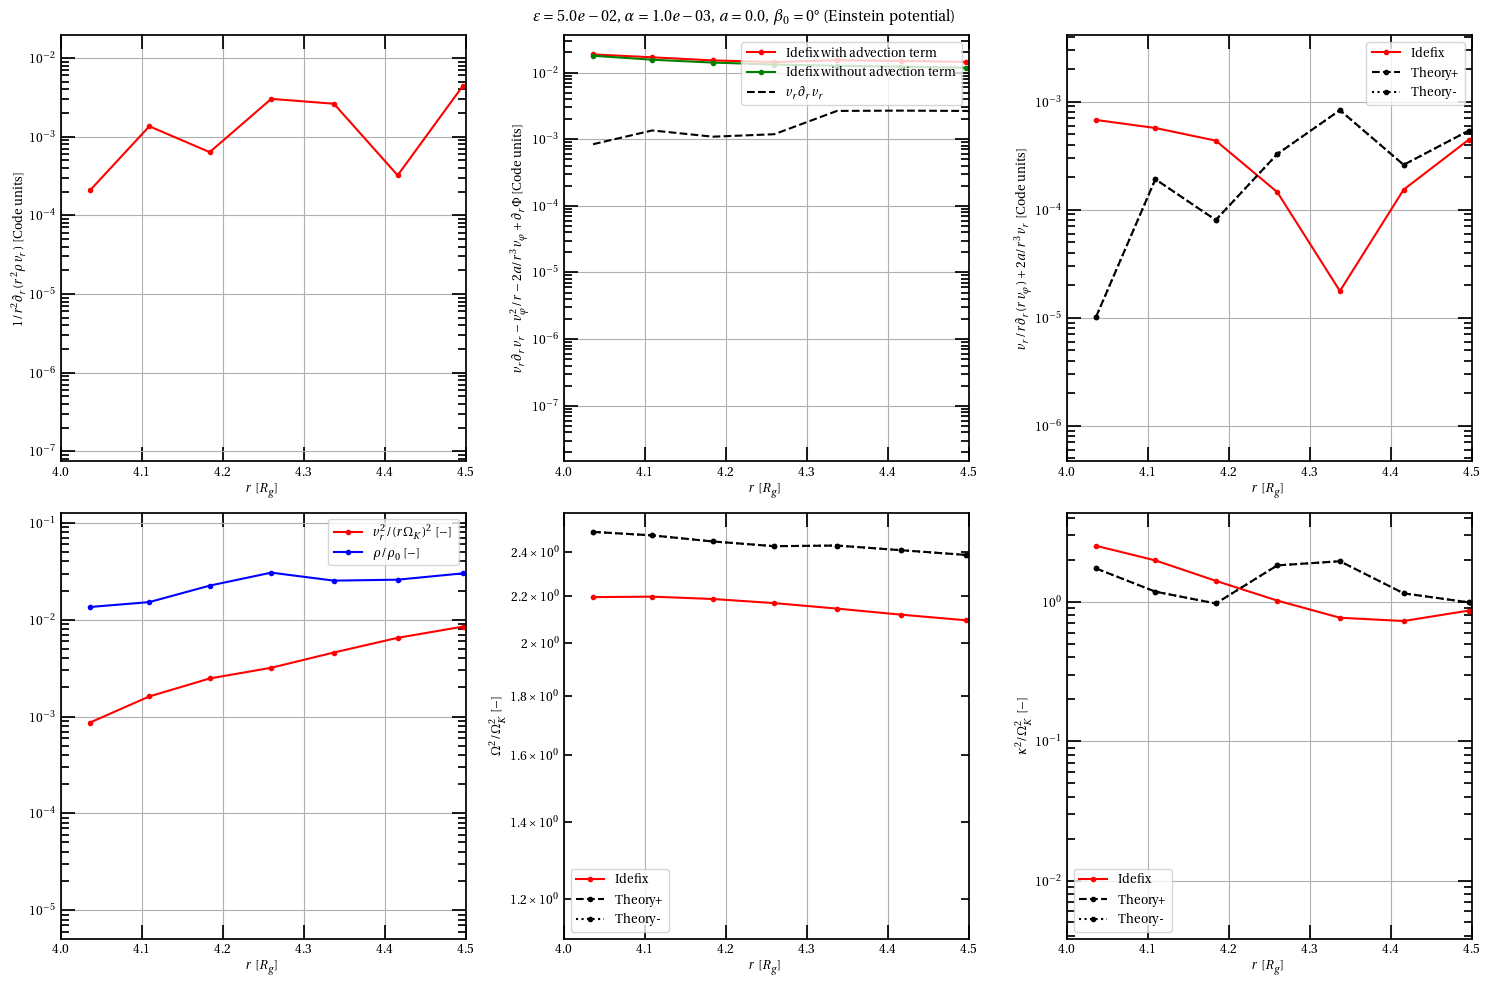

In [5]:
# ----------------------------------------------------------------------------------
# radial equilibrium
# ----------------------------------------------------------------------------------
mass_conservation_PLOT = np.zeros((n_vtk, n_r))
radial_equilibrium_PLOT = np.zeros((n_vtk, n_r))
radial_equilibrium_thp_PLOT = np.zeros((n_vtk, n_r))
radial_equilibrium_thm_PLOT = np.zeros((n_vtk, n_r))
radial_equilibrium2_PLOT = np.zeros((n_vtk, n_r))
radial_equilibrium2_th_PLOT = np.zeros((n_vtk, n_r))
angular_momentum_PLOT = np.zeros((n_vtk, n_r))
angular_momentum_thm_PLOT = np.zeros((n_vtk, n_r))
angular_momentum_thp_PLOT = np.zeros((n_vtk, n_r))
v_r_PLOT = np.zeros((n_vtk, n_r))
rho_mean_PLOT = np.zeros((n_vtk, n_r))
omega_PLOT = np.zeros((n_vtk, n_r))
omega_thm_PLOT = np.zeros((n_vtk, n_r))
omega_thp_PLOT = np.zeros((n_vtk, n_r))
kappa2_PLOT = np.zeros((n_vtk, n_r))
kappa2_thm_PLOT = np.zeros((n_vtk, n_r))
kappa2_thp_PLOT = np.zeros((n_vtk, n_r))

equilibrium_plots = []
for n in range(n_vtk):
    r_vtk, theta_vtk, phi_vtk, rho, v_r, v_theta, v_phi = READ_VTK(n)

    midplane = np.where(theta_vtk >= np.pi/2)[0][0]
    rho = rho[0,midplane,:]
    v_r = v_r[0,midplane,:]
    v_phi = v_phi[0,midplane,:]

    omega = v_phi / r_vtk
    kappa2 = 4*omega**2 + r_vtk*np.gradient(omega**2, r_vtk)
    omega_K = np.sqrt(1/r**3)

    mass_conservation = 1/r_vtk**2 * np.gradient(r_vtk**2 * rho*v_r, r_vtk)
    dr_v_r = np.gradient(v_r, r_vtk)
    if gravity == "Kepler":
        grad_Phi = 1/r_vtk**2
    elif gravity == "Einstein":
        grad_Phi = 1/r_vtk**2 + 6/r_vtk**3
    dr_L = np.gradient(r_vtk*v_phi, r_vtk)
    radial_equilibrium = v_r*dr_v_r - v_phi**2/r_vtk - 2*spin/r_vtk**3*v_phi + grad_Phi
    angular_momentum = v_r/r_vtk * dr_L + 2*spin/r_vtk**3*v_r

    omega_th_p, omega_th_m, kappa2_th_p, kappa2_th_m = THEORETICAL_ROTATION_CURVE(r_vtk, beta_0, spin, gravity, v_r, dr_v_r, r_vtk)
    v_phi_th_p = r_vtk*omega_th_p
    dr_L_th_p = np.gradient(r_vtk*v_phi_th_p, r_vtk)
    radial_equilibrium_th_p = v_r*dr_v_r - v_phi_th_p**2/r_vtk - 2*spin/r_vtk**3*v_phi_th_p + grad_Phi
    angular_momentum_th_p = v_r/r_vtk * dr_L_th_p + 2*spin/r_vtk**3*v_r
    v_phi_th_m = r_vtk*omega_th_m
    dr_L_th_m = np.gradient(r_vtk*v_phi_th_m, r_vtk)
    radial_equilibrium_th_m = v_r*dr_v_r - v_phi_th_m**2/r_vtk - 2*spin/r_vtk**3*v_phi_th_m + grad_Phi
    angular_momentum_th_m = v_r/r_vtk * dr_L_th_m + 2*spin/r_vtk**3*v_r

    mass_conservation_PLOT[n,:] = mass_conservation
    radial_equilibrium_PLOT[n,:] = radial_equilibrium
    radial_equilibrium_thp_PLOT[n,:] = radial_equilibrium_th_p - v_r*dr_v_r
    radial_equilibrium_thm_PLOT[n,:] = radial_equilibrium_th_m - v_r*dr_v_r
    radial_equilibrium2_PLOT[n,:] = radial_equilibrium - v_r*dr_v_r
    radial_equilibrium2_th_PLOT[n,:] = radial_equilibrium_th_m - v_r*dr_v_r
    angular_momentum_PLOT[n,:] = angular_momentum
    angular_momentum_thm_PLOT[n,:] = angular_momentum_th_m
    angular_momentum_thp_PLOT[n,:] = angular_momentum_th_p
    v_r_PLOT[n,:] = v_r
    rho_mean_PLOT[n,:] = rho
    omega_PLOT[n,:] = omega
    omega_thm_PLOT[n,:] = omega_th_m
    omega_thp_PLOT[n,:] = omega_th_p
    kappa2_PLOT[n,:] = kappa2
    kappa2_thm_PLOT[n,:] = kappa2_th_m
    kappa2_thp_PLOT[n,:] = kappa2_th_p

mass_conservation_mean = np.mean(mass_conservation_PLOT, axis=0)
radial_equilibrium_mean = np.mean(radial_equilibrium_PLOT, axis=0)
radial_equilibrium_thp_mean = np.mean(radial_equilibrium_thp_PLOT, axis=0)
radial_equilibrium_thm_mean = np.mean(radial_equilibrium_thm_PLOT, axis=0)
radial_equilibrium2_mean = np.mean(radial_equilibrium2_PLOT, axis=0)
radial_equilibrium2_th_mean = np.mean(radial_equilibrium2_th_PLOT, axis=0)
angular_momentum_mean = np.mean(angular_momentum_PLOT, axis=0)
angular_momentum_thm_mean = np.mean(angular_momentum_thm_PLOT, axis=0)
angular_momentum_thp_mean = np.mean(angular_momentum_thp_PLOT, axis=0)
v_r_mean = np.mean(v_r_PLOT**2, axis=0)
rho_mean_mean = np.mean(rho_mean_PLOT, axis=0)
omega_mean = np.mean(omega_PLOT, axis=0)
omega_thm_mean = np.mean(omega_thm_PLOT, axis=0)
omega_thp_mean = np.mean(omega_thp_PLOT, axis=0)
kappa2_mean = np.mean(kappa2_PLOT, axis=0)
kappa2_thm_mean = np.mean(kappa2_thm_PLOT, axis=0)
kappa2_thp_mean = np.mean(kappa2_thp_PLOT, axis=0)

fig, axs = plt.subplots(2, 3, figsize=(15, 10))

ax = axs[0,0]
ax.plot(r, np.abs(mass_conservation_mean), color="red")
ax.set_xlim((r_min-1, r_max))
ax.set_xlabel(r"$r$ [$R_g$]")
ax.set_yscale("log")
# ax.set_ylim((1e-6, 1e2))
ax.set_ylabel(r"$1/r^2 \partial_r(r^2 \rho v_r)$ [Code units]")
ax.tick_params(axis='y', which='both', direction='in', right=True, width=w, length=l)
ax.tick_params(axis='x', which='both', direction='in', top=True, width=w, length=l)
ax.tick_params(axis='y', which='minor', length=l_log, width=w)
for spine in ax.spines.values():
        spine.set_linewidth(w)
ax.grid()
# ax.legend()

ax = axs[0,1]
ax.plot(r, np.abs(radial_equilibrium_mean), color="red", label=r"Idefix with advection term")
ax.plot(r, np.abs(radial_equilibrium2_mean), color="green", label=r"Idefix without advection term")
ax.plot(r, np.abs(radial_equilibrium_thp_mean), color="black", linestyle="dashed", label=r"$v_r \partial_r v_r$")
ax.set_xlim((r_min-1, r_max))
ax.set_xlabel(r"$r$ [$R_g$]")
ax.set_yscale("log")
# ax.set_ylim((1e-6, 1e2))
ax.set_ylabel(r"$v_r \partial_r v_r - v_\varphi^2/r - 2a/r^3 v_\varphi + \partial_r \Phi$ [Code units]")
ax.tick_params(axis='y', which='both', direction='in', right=True, width=w, length=l)
ax.tick_params(axis='x', which='both', direction='in', top=True, width=w, length=l)
ax.tick_params(axis='y', which='minor', length=l_log, width=w)
for spine in ax.spines.values():
        spine.set_linewidth(w)
ax.grid()
ax.legend(loc="upper right")

ax = axs[0,2]
ax.plot(r, np.abs(angular_momentum_mean), color="red", label=r"Idefix")
ax.plot(r, np.abs(angular_momentum_thp_mean), color="black", linestyle="dashed", label=r"Theory+")
ax.plot(r, np.abs(angular_momentum_thm_mean), color="black", linestyle="dotted", label=r"Theory-")
ax.set_xlim((r_min-1, r_max))
ax.set_xlabel(r"$r$ [$R_g$]")
ax.set_yscale("log")
# ax.set_ylim((1e-6, 1e2))
ax.set_ylabel(r"$v_r/r \partial_r (rv_\varphi) +  2a/r^3 v_r$ [Code units]")
ax.tick_params(axis='y', which='both', direction='in', right=True, width=w, length=l)
ax.tick_params(axis='x', which='both', direction='in', top=True, width=w, length=l)
ax.tick_params(axis='y', which='minor', length=l_log, width=w)
for spine in ax.spines.values():
        spine.set_linewidth(w)
ax.grid()
ax.legend()

ax = axs[1,0]
ax.plot(r, v_r_mean/(r*omega_K)**2, color="red", label=r"$v_r^2/(r\Omega_K)^2$ $[-]$")
ax.plot(r, rho_mean_mean, color="blue", label=r"$\rho/\rho_0$ $[-]$")
ax.set_xlim((r_min-1, r_max))
ax.set_xlabel(r"$r$ [$R_g$]")
ax.set_yscale("log")
# ax.set_ylim((1e-6, 1e2))
ax.tick_params(axis='y', which='both', direction='in', right=True, width=w, length=l)
ax.tick_params(axis='x', which='both', direction='in', top=True, width=w, length=l)
ax.tick_params(axis='y', which='minor', length=l_log, width=w)
for spine in ax.spines.values():
        spine.set_linewidth(w)
ax.grid()
ax.legend()

ax = axs[1,1]
ax.plot(r, omega_mean**2/omega_K**2, color="red", label=r"Idefix")
ax.plot(r, omega_thp_mean**2/omega_K**2, color="black", linestyle="dashed", label=r"Theory+")
ax.plot(r, omega_thm_mean**2/omega_K**2, color="black", linestyle="dotted", label=r"Theory-")
ax.set_xlim((r_min-1, r_max))
ax.set_xlabel(r"$r$ [$R_g$]")
ax.set_yscale("log")
# ax.set_ylim((1e-2, 1e2))
ax.set_ylabel(r"$\Omega^2 / \Omega_K^2$ $[-]$")
ax.tick_params(axis='y', which='both', direction='in', right=True, width=w, length=l)
ax.tick_params(axis='x', which='both', direction='in', top=True, width=w, length=l)
ax.tick_params(axis='y', which='minor', length=l_log, width=w)
for spine in ax.spines.values():
        spine.set_linewidth(w)
ax.grid()
ax.legend()

ax = axs[1,2]
ax.plot(r, kappa2_mean/omega_K**2, color="red", label=r"Idefix")
ax.plot(r, kappa2_thp_mean/omega_K**2, color="black", linestyle="dashed", label=r"Theory+")
ax.plot(r, kappa2_thm_mean/omega_K**2, color="black", linestyle="dotted", label=r"Theory-")
ax.set_xlim((r_min-1, r_max))
ax.set_xlabel(r"$r$ [$R_g$]")
ax.set_yscale("log")
# ax.set_ylim((1e-2, 1e2))
ax.set_ylabel(r"$\kappa^2/\Omega_K^2$ $[-]$")
ax.tick_params(axis='y', which='both', direction='in', right=True, width=w, length=l)
ax.tick_params(axis='x', which='both', direction='in', top=True, width=w, length=l)
ax.tick_params(axis='y', which='minor', length=l_log, width=w)
for spine in ax.spines.values():
        spine.set_linewidth(w)
ax.grid()
ax.legend()

fig.suptitle(rf"$\varepsilon = {epsilon:.1e}$, $\alpha = {alpha:.1e}$, $a = {spin:0.1f}$, $\beta_0 = {beta_0*180/np.pi:.0f}$° ({gravity} potential)")
fig.tight_layout()
plt.savefig(f"./plots/equilibrium.pdf", bbox_inches='tight')
plt.show()
plt.close()

fig, axs = plt.subplots(2, 3, figsize=(15, 10))

ax = axs[0,0]
ax.plot(r, np.abs(mass_conservation_mean), color="red", marker=".")
ax.set_xlim((r_min, r_min+0.5))
ax.set_xlabel(r"$r$ [$R_g$]")
ax.set_yscale("log")
# ax.set_ylim((1e-6, 1e2))
ax.set_ylabel(r"$1/r^2 \partial_r(r^2 \rho v_r)$ [Code units]")
ax.tick_params(axis='y', which='both', direction='in', right=True, width=w, length=l)
ax.tick_params(axis='x', which='both', direction='in', top=True, width=w, length=l)
ax.tick_params(axis='y', which='minor', length=l_log, width=w)
for spine in ax.spines.values():
        spine.set_linewidth(w)
ax.grid()
# ax.legend()

ax = axs[0,1]
ax.plot(r, np.abs(radial_equilibrium_mean), color="red", label=r"Idefix with advection term", marker=".")
ax.plot(r, np.abs(radial_equilibrium2_mean), color="green", label=r"Idefix without advection term", marker=".")
ax.plot(r, np.abs(radial_equilibrium_thp_mean), color="black", linestyle="dashed", label=r"$v_r \partial_r v_r$")
ax.set_xlim((r_min, r_min+0.5))
ax.set_xlabel(r"$r$ [$R_g$]")
ax.set_yscale("log")
# ax.set_ylim((1e-6, 1e2))
ax.set_ylabel(r"$v_r \partial_r v_r - v_\varphi^2/r - 2a/r^3 v_\varphi + \partial_r \Phi$ [Code units]")
ax.tick_params(axis='y', which='both', direction='in', right=True, width=w, length=l)
ax.tick_params(axis='x', which='both', direction='in', top=True, width=w, length=l)
ax.tick_params(axis='y', which='minor', length=l_log, width=w)
for spine in ax.spines.values():
        spine.set_linewidth(w)
ax.grid()
ax.legend(loc="upper right")

ax = axs[0,2]
ax.plot(r, np.abs(angular_momentum_mean), color="red", label=r"Idefix", marker=".")
ax.plot(r, np.abs(angular_momentum_thp_mean), color="black", linestyle="dashed", label=r"Theory+", marker=".")
ax.plot(r, np.abs(angular_momentum_thm_mean), color="black", linestyle="dotted", label=r"Theory-", marker=".")
ax.set_xlim((r_min, r_min+0.5))
ax.set_xlabel(r"$r$ [$R_g$]")
ax.set_yscale("log")
# ax.set_ylim((1e-6, 1e2))
ax.set_ylabel(r"$v_r/r \partial_r (rv_\varphi) +  2a/r^3 v_r$ [Code units]")
ax.tick_params(axis='y', which='both', direction='in', right=True, width=w, length=l)
ax.tick_params(axis='x', which='both', direction='in', top=True, width=w, length=l)
ax.tick_params(axis='y', which='minor', length=l_log, width=w)
for spine in ax.spines.values():
        spine.set_linewidth(w)
ax.grid()
ax.legend()

ax = axs[1,0]
ax.plot(r, v_r_mean/(r*omega_K)**2, color="red", label=r"$v_r^2/(r\Omega_K)^2$ $[-]$", marker=".")
ax.plot(r, rho_mean_mean, color="blue", label=r"$\rho/\rho_0$ $[-]$", marker=".")
ax.set_xlim((r_min, r_min+0.5))
ax.set_xlabel(r"$r$ [$R_g$]")
ax.set_yscale("log")
# ax.set_ylim((1e-6, 1e2))
ax.tick_params(axis='y', which='both', direction='in', right=True, width=w, length=l)
ax.tick_params(axis='x', which='both', direction='in', top=True, width=w, length=l)
ax.tick_params(axis='y', which='minor', length=l_log, width=w)
for spine in ax.spines.values():
        spine.set_linewidth(w)
ax.grid()
ax.legend()

ax = axs[1,1]
ax.plot(r, omega_mean**2/omega_K**2, color="red", label=r"Idefix", marker=".")
ax.plot(r, omega_thp_mean**2/omega_K**2, color="black", linestyle="dashed", label=r"Theory+", marker=".")
ax.plot(r, omega_thm_mean**2/omega_K**2, color="black", linestyle="dotted", label=r"Theory-", marker=".")
ax.set_xlim((r_min, r_min+0.5))
ax.set_xlabel(r"$r$ [$R_g$]")
ax.set_yscale("log")
# ax.set_ylim((1e-2, 1e2))
ax.set_ylabel(r"$\Omega^2 / \Omega_K^2$ $[-]$")
ax.tick_params(axis='y', which='both', direction='in', right=True, width=w, length=l)
ax.tick_params(axis='x', which='both', direction='in', top=True, width=w, length=l)
ax.tick_params(axis='y', which='minor', length=l_log, width=w)
for spine in ax.spines.values():
        spine.set_linewidth(w)
ax.grid()
ax.legend()

ax = axs[1,2]
ax.plot(r, kappa2_mean/omega_K**2, color="red", label=r"Idefix", marker=".")
ax.plot(r, kappa2_thp_mean/omega_K**2, color="black", linestyle="dashed", label=r"Theory+", marker=".")
ax.plot(r, kappa2_thm_mean/omega_K**2, color="black", linestyle="dotted", label=r"Theory-", marker=".")
ax.set_xlim((r_min, r_min+0.5))
ax.set_xlabel(r"$r$ [$R_g$]")
ax.set_yscale("log")
# ax.set_ylim((1e-2, 1e2))
ax.set_ylabel(r"$\kappa^2/\Omega_K^2$ $[-]$")
ax.tick_params(axis='y', which='both', direction='in', right=True, width=w, length=l)
ax.tick_params(axis='x', which='both', direction='in', top=True, width=w, length=l)
ax.tick_params(axis='y', which='minor', length=l_log, width=w)
for spine in ax.spines.values():
        spine.set_linewidth(w)
ax.grid()
ax.legend()

fig.suptitle(rf"$\varepsilon = {epsilon:.1e}$, $\alpha = {alpha:.1e}$, $a = {spin:0.1f}$, $\beta_0 = {beta_0*180/np.pi:.0f}$° ({gravity} potential)")
fig.tight_layout()
plt.savefig(f"./plots/equilibrium_zoom.pdf", bbox_inches='tight')
plt.show()
plt.close()

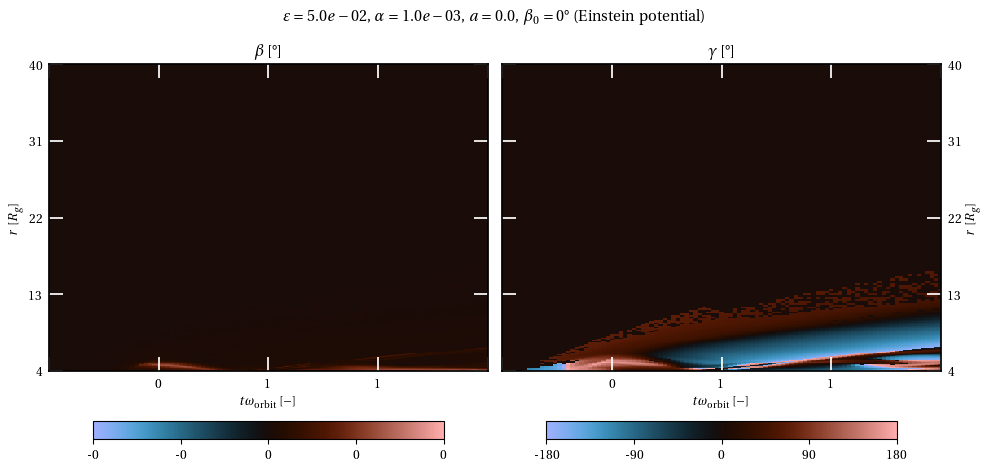

In [7]:
# ----------------------------------------------------------------------------------
# angles color plot
# ----------------------------------------------------------------------------------
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

ax = axs[0]
ax.set_title(r"$\beta$ $[$°$]$")
buff = np.max(np.abs(betaBH))
ticks = np.linspace(-buff, buff, 5)
pc0 = ax.pcolormesh(T, R, betaBH, cmap="berlin", vmin=-buff, vmax=buff)
formats = tkr.FormatStrFormatter('%.0f')
cbar = fig.colorbar(pc0, ax=ax, location="bottom", pad=pad, shrink=shrink, format=formats, ticks=ticks)
ax.tick_params(axis='both', direction='in', color='white', width=w, length=l, pad=lpad)
ax.set_facecolor("black")
ax.set_xlabel(r"$t\omega_\mathrm{orbit}$ $[-]$")
ax.set_ylabel(r"$r$ $[R_g]$")
ax.set_xlim((0, n_orbit))
xplot = np.linspace(0, n_orbit, 5)
xl = [f"{i:.0f}" for i in xplot]
xl[0] = ""
xl[-1] = ""
ax.set_xticks(xplot,xl)
ax.set_ylim((r_min, r_max))
yplot = np.linspace(r_min, r_max, 5)
yl = [f"{i:.0f}" for i in yplot]
ax.set_yticks(yplot, yl)
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
for spine in ax.spines.values():
    spine.set_linewidth(w)

ax = axs[1]
ax.set_title(r"$\gamma$ $[$°$]$")
buff = np.max(np.abs(gammaBH))
ticks = np.linspace(-buff, buff, 5)
pc0 = ax.pcolormesh(T, R, gammaBH, cmap="berlin", vmin=-buff, vmax=buff)
formats = tkr.FormatStrFormatter('%.0f')
cbar = fig.colorbar(pc0, ax=ax, location="bottom", pad=pad, shrink=shrink, format=formats, ticks=ticks)
ax.tick_params(axis='both', direction='in', color='white', width=w, length=l, pad=lpad)
ax.set_facecolor("black")
ax.set_xlabel(r"$t\omega_\mathrm{orbit}$ $[-]$")
ax.set_ylabel(r"$r$ $[R_g]$")
ax.set_xlim((0, n_orbit))
xplot = np.linspace(0, n_orbit, 5)
xl = [f"{i:.0f}" for i in xplot]
xl[0] = ""
xl[-1] = ""
ax.set_xticks(xplot,xl)
ax.set_ylim((r_min, r_max))
yplot = np.linspace(r_min, r_max, 5)
yl = [f"{i:.0f}" for i in yplot]
ax.set_yticks(yplot, yl)
ax.yaxis.set_label_position("right")
ax.yaxis.tick_right()
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
for spine in ax.spines.values():
    spine.set_linewidth(w)

fig.suptitle(rf"$\varepsilon = {epsilon:.1e}$, $\alpha = {alpha:.1e}$, $a = {spin:0.1f}$, $\beta_0 = {beta_0*180/np.pi:.0f}$° ({gravity} potential)")
fig.tight_layout()
plt.savefig(f"./plots/angles.png", bbox_inches='tight', dpi=500)
plt.show()
plt.close()

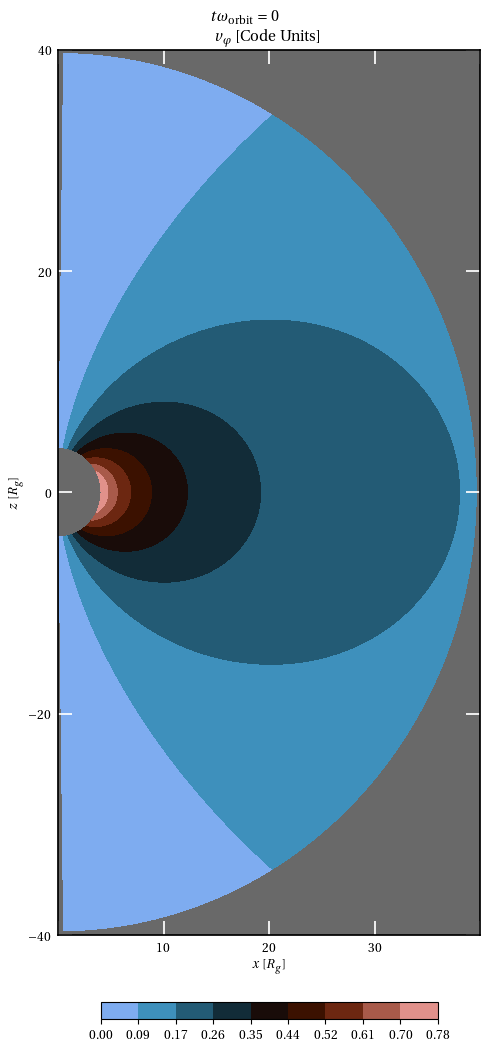

In [9]:
# ----------------------------------------------------------------------------------
# First vtk velocity
# ----------------------------------------------------------------------------------
r_vtk, theta_vtk, phi_vtk, rho, v_r, v_theta, v_phi = READ_VTK(0)
R, TH = np.meshgrid(r_vtk, theta_vtk)
phi_cut_plus = np.where(phi_vtk >= 0)[0][0]
X_cut_plus, Z = R*np.sin(TH)*np.cos(phi_vtk[phi_cut_plus]), R*np.cos(TH)
x_label = r"$x$ [$R_g$]"
y_label = r"$z$ [$R_g$]"

fig, axs = plt.subplots(1, figsize=(5, 12))

ax = axs
ax.set_title(r'$v_\varphi$ $[$Code Units$]$')
buff = np.max(np.abs(v_phi))
levels = np.linspace(0, buff, 10)
pc0 = ax.contourf(X_cut_plus, Z, v_phi[phi_cut_plus,:,:], cmap="berlin", levels=levels)
formats = tkr.FormatStrFormatter('%.2f')
cbar = fig.colorbar(pc0, ax=ax, location="bottom", pad=pad/2, shrink=shrink, format=formats, ticks=levels)
ax.tick_params(axis='both', direction='in', color='white', width=w, length=l, pad=lpad)
ax.set_facecolor("dimgray")
ax.set_xlabel(x_label)
ax.set_ylabel(y_label)
ax.set_xlim((0,r_max))
xplot = np.linspace(0, r_max, 5)
xl = [f"{i:.0f}" for i in xplot]
xl[0] = ""
xl[-1] = ""
ax.set_xticks(xplot,xl)
ax.set_ylim((-r_max, r_max))
yplot = np.linspace(-r_max, r_max, 5)
ax.set_yticks(yplot)
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
for spine in ax.spines.values():
    spine.set_linewidth(w)

fig.suptitle(r"$t\omega_\mathrm{orbit} = 0$ ", x=0.5, y=0.98)
fig.tight_layout()
plt.savefig(f"./plots/Vphi_0_{gravity}.png", bbox_inches='tight', dpi=300)
plt.show()
plt.close()

In [10]:
mass_plots = []
mass_zoom_plots = []
velocity_plots = []
velocity_zoom_plots = []
source_term_plots = []

for n in range(n_vtk):
    n_analysis = int(n * conf["Output"]["vtk"] // conf["Output"]["analysis"])
    r_vtk, theta_vtk, phi_vtk, rho, v_r, v_theta, v_phi = READ_VTK(n)
    PHI, TH, R = np.meshgrid(phi_vtk, theta_vtk, r_vtk, indexing="ij")

    c_s = epsilon / np.sqrt(R)
    mask = (rho > densityFloor * 2)

    # mass plots ----------------------------------------------------------------------------------------------------------------------------------------
    # fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    # ax = axs[0]
    # Sigma /= Sigma[0,:]
    # ax.plot(r, Sigma[n_analysis,:], color="tab:red")
    # ax.set_xlim((0, r_max))
    # xplot = np.linspace(0, r_max , 7)
    # xl = [f"{i:.0f}" for i in xplot]
    # xl[0] = ""
    # xl[-1] = ""
    # ax.set_xticks(xplot, xl)
    # ax.set_xlabel(r"$r$ $[R_g]$")
    # ax.set_ylim((1e-4, 1e2))
    # ax.set_yscale("log")
    # ax.set_ylabel(r"$\Sigma/\Sigma(t=0)$ $[-]$")
    # ax.tick_params(axis='x', which='both', direction='in', top=True, width=w, length=l)
    # ax.tick_params(axis='y', which='both', direction='in', right=True, width=w, length=l)
    # ax.tick_params(axis='y', which='minor', length=l_log, width=w)
    # ax.yaxis.set_ticks_position('both')
    # ax.xaxis.set_ticks_position('both')
    # for spine in ax.spines.values():
    #         spine.set_linewidth(w)
    # ax.grid()

    # ax = axs[1]
    # ax.plot(r, M_dot[n_analysis,:], color="tab:orange")
    # ax.set_xlim((0, r_max))
    # xplot = np.linspace(0, r_max , 7)
    # xl = [f"{i:.0f}" for i in xplot]
    # xl[0] = ""
    # xl[-1] = ""
    # ax.set_xticks(xplot, xl)
    # ax.set_xlabel(r"$r$ $[R_g]$")
    # ax.set_ylim((1e-4, 1e2))
    # ax.set_yscale("log")
    # ax.set_ylabel(r"$\dot{M}/\dot{M}_\text{visc}$ $[-]$")
    # ax.yaxis.set_label_position("right")
    # ax.yaxis.set_ticks_position("right")
    # ax.tick_params(axis='x', which='both', direction='in', top=True, width=w, length=l)
    # ax.tick_params(axis='y', which='both', direction='in', right=True, width=w, length=l)
    # ax.tick_params(axis='y', which='minor', length=l_log, width=w)
    # ax.yaxis.set_ticks_position('both')
    # ax.xaxis.set_ticks_position('both')
    # for spine in ax.spines.values():
    #         spine.set_linewidth(w)
    # ax.grid()

    # fig.suptitle(r"$t\omega_\mathrm{orbit} =$ " + f"{t[n_analysis]:.0f}")
    # fig.tight_layout()
    # plt.savefig(f"./output/plots/mass_{n}.png", bbox_inches='tight', dpi=300)
    # plt.close()
    # mass_plots.append(f"./output/plots/mass_{n}.png")

    quantities = {
        "densityFloor": densityFloor,
        "rho": rho,
        "v_r": v_r,
        "v_theta": v_theta,
    }
    MASS_PLOT(r_vtk, r_min, r_max, theta_vtk, phi_vtk, quantities, False, mass_plots, f"mass_{n}", t[n_analysis])
    MASS_PLOT(r_vtk, r_min, r_max, theta_vtk, phi_vtk, quantities, True, mass_zoom_plots, f"mass_zoom_{n}", t[n_analysis])

    quantities = {
        "q_r": v_r*mask,
        "q_th": v_theta*mask,
        "q_phi": v_phi*mask,
        "title_r": r"$v_r$ $[$Code Units$]$",
        "title_th": r"$v_\theta$ $[$Code Units$]$",
        "title_phi": r"$v_\varphi$ $[$Code Units$]$"
    }
    VELOCITY_PLOT(r_vtk, r_min, r_max, theta_vtk, phi_vtk, quantities, False, velocity_plots, f"velocity_{n}", t[n_analysis])
    VELOCITY_PLOT(r_vtk, r_min, r_max, theta_vtk, phi_vtk, quantities, True, velocity_zoom_plots, f"velocity_zoom_{n}", t[n_analysis])

    Sx = np.sin(-beta_0) * spin
    Sy = 0
    Sz = np.cos(-beta_0) * spin
    Sr = np.sin(TH)*np.cos(PHI)*Sx + np.sin(TH)*np.sin(PHI)*Sy + np.cos(TH)*Sz
    Sth = np.cos(TH)*np.cos(PHI)*Sx + np.cos(TH)*np.sin(PHI)*Sy - np.sin(TH)*Sz
    Sphi = - np.sin(PHI)*Sx + np.cos(PHI)*Sy
    hr = -4*Sr / R**3
    hth = 2*Sth / R**3
    hphi = 2*Sphi / R**3
    Vcrossh_r = v_theta*hphi - v_phi*hth
    Vcrossh_th = v_phi*hr - v_r*hphi
    Vcrossh_phi = v_r*hth - v_theta*hr

    quantities = {
        "q_r": Vcrossh_r*mask,
        "q_th": Vcrossh_th*mask,
        "q_phi": Vcrossh_phi*mask,
        "title_r": r'$(v\times h)_r$ $[$Code Units$]$',
        "title_th": r'$(v\times h)_\theta$ $[$Code Units$]$',
        "title_phi": r'$(v\times h)_\varphi$ $[$Code Units$]$'
    }
    VELOCITY_PLOT(r_vtk, r_min, r_max, theta_vtk, phi_vtk, quantities, True, source_term_plots, f"source_term_{n}", t[n_analysis])
MOVIE(mass_plots, "mass")
MOVIE(mass_zoom_plots, "mass_zoom")
MOVIE(velocity_plots, "velocity")
MOVIE(velocity_zoom_plots, "velocity_zoom")
MOVIE(source_term_plots, "source_term")

/Users/geoffrey_marty/Desktop/stage/TiltedDisk/src.py:391: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/Users/geoffrey_marty/Desktop/stage/TiltedDisk/src.py:391: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/Users/geoffrey_marty/Desktop/stage/TiltedDisk/src.py:391: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/Users/geoffrey_marty/Desktop/stage/TiltedDisk/src.py:391: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/Users/geoffrey_marty/Desktop/stage/TiltedDisk/src.py:391: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/Users/geoffrey_marty/Desktop/stage